## 1. Setup and Data Sources

In [1]:
import pandas as pd
import numpy as np
import requests
import json
import gzip
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
from io import StringIO
import warnings
warnings.filterwarnings('ignore')

# Set plot style
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.size'] = 10
sns.set_palette("colorblind")

print("Packages loaded successfully")

Packages loaded successfully


## 2. Define Gene Set

Our melanogenesis genes are classified by **clinical phenotype**:

| Category | Definition | Prediction |
|----------|------------|------------|
| **Pigmentation-restricted** | LOF causes isolated pigmentation phenotypes | Higher LOEUF (tolerant) |
| **Pleiotropic/Syndromic** | LOF causes multi-system disorders | Lower LOEUF (constrained) |

This classification directly tests the hypothesis: **selection constrains pleiotropic genes, 
so common pigmentation variants can only arise in pigmentation-restricted genes**.

In [2]:
# Define the melanogenesis gene set by clinical phenotype classification

gene_set = {
    # Pigmentation-restricted: LOF primarily causes isolated pigmentation phenotypes
    'pigment_restricted': [
        # Core enzymes (isolated OCA)
        'TYR', 'TYRP1', 'DCT',
        # Melanosomal transporters (isolated OCA types)
        'OCA2', 'SLC45A2', 'SLC24A5',
        # Pigmentation signaling (red hair, skin color variants)
        'MC1R', 'ASIP',
        # Melanocyte-specific proteins
        'MLANA', 'TPCN2', 'MFSD12', 'GPR143',
        # Pigmentation modifiers
        'HERC2', 'IRF4',
        # Griscelli type 3 (pigment only, no immune/neuro)
        'MLPH'
    ],
    
    # Pleiotropic: LOF causes multi-system syndromes beyond pigmentation
    'pleiotropic': [
        # HPS complex (bleeding diathesis, pulmonary fibrosis, colitis + pigment)
        'HPS1', 'HPS3', 'HPS4', 'HPS5', 'HPS6',
        # AP-3 complex (HPS2/10 - immune deficiency + pigment)
        'AP3B1', 'AP3D1',
        # BLOC-1 complex (HPS7-9, neuropsychiatric associations)
        'BLOC1S1', 'BLOC1S2', 'BLOC1S3', 'BLOC1S4', 'BLOC1S5', 'BLOC1S6', 'DTNBP1',
        # Waardenburg syndrome genes (deafness, Hirschsprung + pigment)
        'MITF', 'SOX10', 'PAX3', 'EDNRB', 'EDN1',
        # Griscelli syndrome types 1-2 (neurological/immune + pigment)
        'RAB27A', 'MYO5A',
        # Piebaldism/hematopoiesis (GI stromal tumors, germ cells)
        'KIT', 'KITLG',
        # Other syndromic
        'ATP7A',   # Menkes disease (severe neurological)
        'POMC',    # Obesity, adrenal insufficiency
        'PMEL', 'RAB32', 'RAB38', 'TFEC'
    ]
}

# Flatten to dataframe
gene_data = []
for category, genes in gene_set.items():
    for gene in genes:
        gene_data.append({'gene_symbol': gene, 'category': category})

df_genes = pd.DataFrame(gene_data)
print(f"Total genes in analysis: {len(df_genes)}")
print(f"\nGenes per category:")
print(df_genes['category'].value_counts())

print("\n" + "="*70)
print("PIGMENTATION-RESTRICTED genes (n={})".format(len(gene_set['pigment_restricted'])))
print("="*70)
print(gene_set['pigment_restricted'])

print("\n" + "="*70)
print("PLEIOTROPIC genes (n={})".format(len(gene_set['pleiotropic'])))
print("="*70)
print(gene_set['pleiotropic'])

Total genes in analysis: 44

Genes per category:
category
pleiotropic           29
pigment_restricted    15
Name: count, dtype: int64

PIGMENTATION-RESTRICTED genes (n=15)
['TYR', 'TYRP1', 'DCT', 'OCA2', 'SLC45A2', 'SLC24A5', 'MC1R', 'ASIP', 'MLANA', 'TPCN2', 'MFSD12', 'GPR143', 'HERC2', 'IRF4', 'MLPH']

PLEIOTROPIC genes (n=29)
['HPS1', 'HPS3', 'HPS4', 'HPS5', 'HPS6', 'AP3B1', 'AP3D1', 'BLOC1S1', 'BLOC1S2', 'BLOC1S3', 'BLOC1S4', 'BLOC1S5', 'BLOC1S6', 'DTNBP1', 'MITF', 'SOX10', 'PAX3', 'EDNRB', 'EDN1', 'RAB27A', 'MYO5A', 'KIT', 'KITLG', 'ATP7A', 'POMC', 'PMEL', 'RAB32', 'RAB38', 'TFEC']


## 3. Get Constraint Data from gnomAD

**Source:** gnomAD v2.1.1 constraint metrics

We use LOEUF (loss-of-function observed/expected upper bound fraction):
- LOEUF < 0.35 = highly constrained (LoF variants are deleterious)
- LOEUF > 1.0 = tolerant (LoF variants are viable)

In [3]:
# Option 1: If you have the gnomAD file locally
# Uncomment and modify path as needed:
# gnomad_file = '../data/gnomad.v2.1.1.lof_metrics.by_gene.txt.bgz'

# Option 2: Download from gnomAD (recommended)
def get_gnomad_constraint(genes):
    """
    Get constraint metrics from gnomAD for a list of genes.
    Uses the gnomAD API or downloads the constraint file.
    """
    
    # Try to load from local file first
    local_files = [
        '../data/gnomad.v2.1.1.lof_metrics.by_gene.txt.bgz',
        '../data/gnomad_v2_1_1_lof_metrics_by_transcript_txt.bgz',
        '../data/constraint_metrics.tsv'
    ]
    
    for f in local_files:
        try:
            if f.endswith('.bgz'):
                with gzip.open(f, 'rt') as fh:
                    df = pd.read_csv(fh, sep='\t')
            else:
                df = pd.read_csv(f, sep='\t')
            print(f"Loaded constraint data from {f}")
            return df
        except FileNotFoundError:
            continue
    
    # If no local file, try downloading
    print("Downloading gnomAD constraint data...")
    url = "https://storage.googleapis.com/gcp-public-data--gnomad/release/2.1.1/constraint/gnomad.v2.1.1.lof_metrics.by_gene.txt.bgz"
    
    try:
        response = requests.get(url, stream=True, timeout=60)
        if response.status_code == 200:
            with open('../data/gnomad_constraint.txt.bgz', 'wb') as f:
                f.write(response.content)
            with gzip.open('../data/gnomad_constraint.txt.bgz', 'rt') as fh:
                df = pd.read_csv(fh, sep='\t')
            print("Downloaded and loaded gnomAD constraint data")
            return df
    except Exception as e:
        print(f"Could not download: {e}")
    
    print("ERROR: Could not load gnomAD constraint data.")
    print("Please download from: https://gnomad.broadinstitute.org/downloads#v2-constraint")
    return None

# Try to get constraint data
gnomad_df = get_gnomad_constraint(df_genes['gene_symbol'].tolist())

Downloaded and loaded gnomAD constraint data


In [4]:
# If gnomAD loaded successfully, merge with our gene set
if gnomad_df is not None:
    # Get canonical transcripts only
    if 'canonical' in gnomad_df.columns:
        gnomad_df = gnomad_df[gnomad_df['canonical'] == True]
    
    # Standardize gene names
    gnomad_df['gene_upper'] = gnomad_df['gene'].str.upper()
    df_genes['gene_upper'] = df_genes['gene_symbol'].str.upper()
    
    # Merge
    df = df_genes.merge(
        gnomad_df[['gene_upper', 'oe_lof_upper', 'pLI']],
        on='gene_upper',
        how='left'
    )
    
    # Rename columns
    df = df.rename(columns={'oe_lof_upper': 'LOEUF'})
    df = df.drop(columns=['gene_upper'])
    
    print(f"\nGenes with LOEUF data: {df['LOEUF'].notna().sum()}/{len(df)}")
    print(f"\nLOEUF summary by category:")
    print(df.groupby('category')['LOEUF'].describe().round(2))
else:
    print("Skipping constraint merge - no data available")
    df = df_genes.copy()
    df['LOEUF'] = np.nan
    df['pLI'] = np.nan


Genes with LOEUF data: 44/44

LOEUF summary by category:
                    count  mean   std   min   25%   50%   75%   max
category                                                           
pigment_restricted   15.0  1.17  0.61  0.20  0.77  1.16  1.73  1.97
pleiotropic          29.0  0.91  0.55  0.21  0.42  0.73  1.29  1.91


## 4. Get GWAS Data from GWAS Catalog

**Source:** NHGRI-EBI GWAS Catalog API

We query for pigmentation-related traits and extract:
- Gene names
- Variant functional consequences (CONTEXT field)
- Population/ancestry information

In [5]:
# Better approach: Get ALL traits and filter for pigmentation-related ones

import requests
import pandas as pd
import time

def get_all_traits(page_size=500):
    """Get all EFO traits from GWAS Catalog and filter for pigmentation."""
    
    url = "https://www.ebi.ac.uk/gwas/rest/api/efoTraits"
    all_traits = []
    page = 0
    
    while True:
        print(f"Fetching page {page}...")
        response = requests.get(url, params={'size': page_size, 'page': page}, timeout=60)
        
        if response.status_code != 200:
            print(f"Error: {response.status_code}")
            break
            
        data = response.json()
        
        if '_embedded' not in data or 'efoTraits' not in data['_embedded']:
            break
            
        traits = data['_embedded']['efoTraits']
        if not traits:
            break
            
        all_traits.extend(traits)
        
        # Check if there are more pages
        if 'page' in data and data['page']['number'] >= data['page']['totalPages'] - 1:
            break
            
        page += 1
        time.sleep(0.3)
    
    return all_traits

print("="*70)
print("FETCHING ALL GWAS CATALOG TRAITS")
print("="*70)

all_traits = get_all_traits()
print(f"\nTotal traits in GWAS Catalog: {len(all_traits)}")

# Convert to dataframe for easy filtering
df_traits = pd.DataFrame([
    {'efo_id': t['shortForm'], 'trait': t['trait']} 
    for t in all_traits
])

# Filter for pigmentation-related terms
pigment_keywords = [
    'pigment', 'skin', 'eye', 'hair', 'color', 'colour', 'melanin', 
    'tanning', 'freckl', 'iris', 'albinism', 'vitiligo'
]

def is_pigmentation_trait(trait_name):
    trait_lower = trait_name.lower()
    return any(kw in trait_lower for kw in pigment_keywords)

df_pigment = df_traits[df_traits['trait'].apply(is_pigmentation_trait)]

print(f"\n" + "="*70)
print(f"PIGMENTATION-RELATED TRAITS: {len(df_pigment)}")
print("="*70)
print(df_pigment.to_string(index=False))

FETCHING ALL GWAS CATALOG TRAITS
Fetching page 0...
Fetching page 1...
Fetching page 2...
Fetching page 3...
Fetching page 4...
Fetching page 5...
Fetching page 6...
Fetching page 7...
Fetching page 8...
Fetching page 9...
Fetching page 10...
Fetching page 11...
Fetching page 12...
Fetching page 13...
Fetching page 14...
Fetching page 15...
Fetching page 16...
Fetching page 17...
Fetching page 18...
Fetching page 19...
Fetching page 20...
Fetching page 21...
Fetching page 22...
Fetching page 23...
Fetching page 24...
Fetching page 25...
Fetching page 26...
Fetching page 27...
Fetching page 28...
Fetching page 29...
Fetching page 30...
Fetching page 31...
Fetching page 32...
Fetching page 33...
Fetching page 34...
Fetching page 35...
Fetching page 36...
Fetching page 37...
Fetching page 38...
Fetching page 39...
Fetching page 40...
Fetching page 41...

Total traits in GWAS Catalog: 20990

PIGMENTATION-RELATED TRAITS: 120
         efo_id                                                   

In [6]:
# STEP 2: Get associations for the REAL pigmentation traits

import requests
import pandas as pd
import time

def get_trait_associations(efo_id, trait_name):
    """Get all associations for a trait, with genes and functional class."""
    
    url = f"https://www.ebi.ac.uk/gwas/rest/api/efoTraits/{efo_id}/associations"
    
    try:
        response = requests.get(url, params={'size': 1000}, timeout=60)
        
        if response.status_code != 200:
            print(f"  {efo_id}: API returned {response.status_code}")
            return []
        
        data = response.json()
        
        if '_embedded' not in data or 'associations' not in data['_embedded']:
            print(f"  {efo_id}: No associations found")
            return []
        
        associations = data['_embedded']['associations']
        print(f"  {efo_id} ({trait_name}): {len(associations)} associations")
        
        results = []
        for assoc in associations:
            pval = assoc.get('pvalue')
            
            for locus in assoc.get('loci', []):
                # Get SNP ID from risk allele
                snp_id = None
                risk_allele = None
                for ra in locus.get('strongestRiskAlleles', []):
                    risk_allele = ra.get('riskAlleleName', '')
                    if '-' in risk_allele:
                        snp_id = risk_allele.split('-')[0]
                
                # Get genes
                for g in locus.get('authorReportedGenes', []):
                    gene_name = g.get('geneName', '')
                    if gene_name and gene_name.lower() not in ['intergenic', 'nr', '', 'n/a']:
                        results.append({
                            'efo_id': efo_id,
                            'trait': trait_name,
                            'gene': gene_name.upper(),
                            'snp_id': snp_id,
                            'pvalue': pval
                        })
        
        return results
        
    except Exception as e:
        print(f"  {efo_id}: Error - {e}")
        return []


# Query the real pigmentation traits
pigmentation_traits = {
    'EFO_0003924': 'hair color',
    'EFO_0003949': 'eye color',
    'EFO_0003963': 'freckles',
    'EFO_0009764': 'eye colour measurement',
    'OBA_VT0002095': 'skin pigmentation',
    'OBA_2045282': 'facial pigmentation',
    'EFO_0021835': 'melanin measurement',
    'EFO_0004795': 'skin sensitivity to sun',
}

print("="*70)
print("FETCHING ASSOCIATIONS FOR PIGMENTATION TRAITS")
print("="*70)

all_associations = []

for efo_id, trait_name in pigmentation_traits.items():
    results = get_trait_associations(efo_id, trait_name)
    all_associations.extend(results)
    time.sleep(0.5)

# Create dataframe
gwas_df = pd.DataFrame(all_associations)

print(f"\n" + "="*70)
print(f"TOTAL: {len(gwas_df)} gene-trait associations")
print(f"UNIQUE GENES: {gwas_df['gene'].nunique()}")
print("="*70)

print("\nTop 30 genes by association count:")
print(gwas_df['gene'].value_counts().head(30))

print("\nAssociations by trait:")
print(gwas_df['trait'].value_counts())

# Save
gwas_df.to_csv('gwas_pigmentation_associations.csv', index=False)
print("\nSaved to: gwas_pigmentation_associations.csv")

FETCHING ASSOCIATIONS FOR PIGMENTATION TRAITS
  EFO_0003924 (hair color): 556 associations
  EFO_0003949 (eye color): 201 associations
  EFO_0003963 (freckles): 30 associations
  EFO_0009764 (eye colour measurement): 202 associations
  OBA_VT0002095 (skin pigmentation): 543 associations
  OBA_2045282 (facial pigmentation): 52 associations
  EFO_0021835 (melanin measurement): 1 associations
  EFO_0004795 (skin sensitivity to sun): 85 associations

TOTAL: 723 gene-trait associations
UNIQUE GENES: 318

Top 30 genes by association count:
gene
OCA2       58
MC1R       48
HERC2      40
IRF4       36
SLC45A2    23
TYR        17
SLC24A4    17
SLC24A5    14
KITLG      12
TYRP1      11
BNC2       10
TCF25       9
ASIP        8
TPCN2       8
GRM5        6
EPHA4       6
MFSD12      5
EXOC2       5
RALY        4
TMTC3       4
FANCA       4
DSTYK       4
DEF8        4
AKAP12      3
LHX2        3
PPFIBP2     3
SLC45A1     3
CDK10       3
PAX3        3
EZR         3
Name: count, dtype: int64

Associat

In [7]:
# STEP 3: Get functional class for each unique SNP

import requests
import time

def get_snp_functional_class(snp_id):
    """Get functional class for a SNP from GWAS Catalog."""
    
    if not snp_id or not snp_id.startswith('rs'):
        return None
    
    url = f"https://www.ebi.ac.uk/gwas/rest/api/singleNucleotidePolymorphisms/{snp_id}"
    
    try:
        response = requests.get(url, timeout=30)
        if response.status_code == 200:
            data = response.json()
            return data.get('functionalClass')
        return None
    except:
        return None


# Get unique SNPs
unique_snps = gwas_df['snp_id'].dropna().unique()
print(f"Fetching functional class for {len(unique_snps)} unique SNPs...")
print("(This may take a few minutes)")

snp_func_classes = {}

for i, snp_id in enumerate(unique_snps):
    func_class = get_snp_functional_class(snp_id)
    if func_class:
        snp_func_classes[snp_id] = func_class
    
    if (i + 1) % 20 == 0:
        print(f"  Processed {i + 1}/{len(unique_snps)} SNPs...")
    
    time.sleep(0.15)  # Rate limiting

print(f"\nGot functional class for {len(snp_func_classes)} SNPs")

# Add to dataframe
gwas_df['functional_class'] = gwas_df['snp_id'].map(snp_func_classes)

print("\n" + "="*70)
print("FUNCTIONAL CLASS DISTRIBUTION")
print("="*70)
print(gwas_df['functional_class'].value_counts())

# Classify as coding vs regulatory
def classify_variant(func_class):
    if pd.isna(func_class):
        return 'unknown'
    
    func_lower = func_class.lower()
    
    # Coding variants
    if any(x in func_lower for x in ['missense', 'nonsense', 'frameshift', 'stop_gained', 
                                       'stop_lost', 'start_lost', 'splice_donor', 'splice_acceptor']):
        return 'coding'
    
    # Regulatory variants
    if any(x in func_lower for x in ['intron', 'upstream', 'downstream', 'intergenic', 
                                       'regulatory', 'enhancer', '3_prime', '5_prime', 
                                       'non_coding', 'synonymous']):
        return 'regulatory'
    
    return 'other'

gwas_df['variant_type'] = gwas_df['functional_class'].apply(classify_variant)

print("\n" + "="*70)
print("VARIANT TYPE CLASSIFICATION")
print("="*70)
print(gwas_df['variant_type'].value_counts())

# Summary by gene
print("\n" + "="*70)
print("GENES BY VARIANT TYPE")
print("="*70)

gene_summary = gwas_df.groupby('gene').agg({
    'variant_type': lambda x: ', '.join(sorted(set(x))),
    'snp_id': 'nunique',
    'functional_class': lambda x: ', '.join(sorted(set(x.dropna())))
}).rename(columns={'snp_id': 'n_snps', 'functional_class': 'func_classes'})

# Filter to genes with known variant type
gene_summary = gene_summary[~gene_summary['variant_type'].str.contains('unknown')]
gene_summary = gene_summary.sort_values('n_snps', ascending=False)

print(gene_summary.head(30).to_string())

# Save
gwas_df.to_csv('gwas_pigmentation_with_functional_class.csv', index=False)
gene_summary.to_csv('gwas_gene_summary.csv')
print("\nSaved to: gwas_pigmentation_with_functional_class.csv")
print("Saved to: gwas_gene_summary.csv")

Fetching functional class for 474 unique SNPs...
(This may take a few minutes)
  Processed 20/474 SNPs...
  Processed 40/474 SNPs...
  Processed 60/474 SNPs...
  Processed 80/474 SNPs...
  Processed 100/474 SNPs...
  Processed 120/474 SNPs...
  Processed 140/474 SNPs...
  Processed 160/474 SNPs...
  Processed 180/474 SNPs...
  Processed 200/474 SNPs...
  Processed 220/474 SNPs...
  Processed 240/474 SNPs...
  Processed 260/474 SNPs...
  Processed 280/474 SNPs...
  Processed 300/474 SNPs...
  Processed 320/474 SNPs...
  Processed 340/474 SNPs...
  Processed 360/474 SNPs...
  Processed 380/474 SNPs...
  Processed 400/474 SNPs...
  Processed 420/474 SNPs...
  Processed 440/474 SNPs...
  Processed 460/474 SNPs...

Got functional class for 468 SNPs

FUNCTIONAL CLASS DISTRIBUTION
functional_class
intron_variant                         449
missense_variant                       100
intergenic_variant                      87
regulatory_region_variant               27
3_prime_UTR_variant       

## 6. Merge Data and Annotate

In [8]:
# STEP 4: Classify as coding vs regulatory and summarize by gene

def classify_variant(func_class):
    if pd.isna(func_class):
        return 'unknown'
    
    func_lower = func_class.lower()
    
    # Coding variants
    if any(x in func_lower for x in ['missense', 'nonsense', 'frameshift', 'stop_gained', 
                                       'stop_lost', 'start_lost', 'splice_donor', 'splice_acceptor']):
        return 'coding'
    
    # Regulatory/non-coding variants
    if any(x in func_lower for x in ['intron', 'upstream', 'downstream', 'intergenic', 
                                       'regulatory', 'enhancer', '3_prime', '5_prime', 
                                       'non_coding', 'synonymous']):
        return 'regulatory'
    
    return 'other'

gwas_df['variant_type'] = gwas_df['functional_class'].apply(classify_variant)

print("Variant type distribution:")
print(gwas_df['variant_type'].value_counts())

# Create gene-level summary: for each gene, what variant types does it have?
gene_variant_types = gwas_df.groupby('gene')['variant_type'].apply(
    lambda x: 'coding' if 'coding' in x.values else ('regulatory' if 'regulatory' in x.values else 'unknown')
).reset_index()
gene_variant_types.columns = ['gene', 'variant_type']

print(f"\nGene-level variant type summary:")
print(gene_variant_types['variant_type'].value_counts())

# Show genes by type
print("\nCODING genes:")
print(gene_variant_types[gene_variant_types['variant_type'] == 'coding']['gene'].tolist())

print("\nREGULATORY genes:")
print(gene_variant_types[gene_variant_types['variant_type'] == 'regulatory']['gene'].tolist())

Variant type distribution:
variant_type
regulatory    603
coding        105
unknown         8
other           7
Name: count, dtype: int64

Gene-level variant type summary:
variant_type
regulatory    294
coding         17
unknown         7
Name: count, dtype: int64

CODING genes:
['DSTYK', 'FREM2', 'KRT31', 'MC1R', 'MFSD12', 'MIR3164', 'MSX2', 'OCA2', 'PADI3', 'PLXNB2', 'SLC12A9', 'SLC24A5', 'SLC45A2', 'TPCN2', 'TYR', 'WFDC5', 'ZNF304']

REGULATORY genes:
['AC004938.5', 'AC005358.1', 'AC007347.1', 'AC008940.1', 'AC012074.2', 'AC018696.4', 'AC060226.1', 'ADAMTSL1', 'ADCY8/EFR3A', 'ADD3', 'ADGRV1', 'AFG3L1P', 'AFM', 'AHNAK', 'AKAP1', 'AKAP12', 'AL121904.1', 'AMPD3', 'AP3M2', 'APBA2', 'APBB2', 'AREG', 'ARHGAP20', 'ARHGAP24', 'ARHGAP32', 'ARID1B', 'ARL15', 'AS1', 'ASIP', 'ATP10A', 'ATP1B3', 'ATXN10', 'ATXN7L1', 'AXIN2', 'BABAM2', 'BBS5', 'BCAS1', 'BCN2', 'BMP4', 'BNC1', 'BNC2', 'C16ORF55', 'C1ORF127', 'C1ORF95', 'C2ORF91', 'C4ORF22', 'C8ORF31', 'C9ORF66', 'CBFA2T3', 'CCDC26', 'CCND1', 'CCND

In [9]:
# STEP 5: Merge GWAS annotations with our melanogenesis pathway genes

# df should already have your melanogenesis genes with LOEUF
# gene_variant_types has the GWAS-derived variant classifications

df['gene_upper'] = df['gene_symbol'].str.upper()
gene_variant_types['gene_upper'] = gene_variant_types['gene'].str.upper()

# Merge
df = df.merge(
    gene_variant_types[['gene_upper', 'variant_type']],
    on='gene_upper',
    how='left'
)

# Drop the temporary column
df = df.drop(columns=['gene_upper'])

# Fill NaN with 'none' (no GWAS hit)
df['variant_type'] = df['variant_type'].fillna('none')

print("Merged dataset:")
print(df['variant_type'].value_counts())

print("\n" + "="*70)
print("PIGMENTATION-RESTRICTED genes with GWAS hits:")
print("="*70)
restricted_gwas = df[(df['category'] == 'pigment_restricted') & (df['variant_type'] != 'none')]
print(restricted_gwas[['gene_symbol', 'LOEUF', 'variant_type']].to_string())

print("\n" + "="*70)
print("PLEIOTROPIC genes with GWAS hits:")
print("="*70)
pleio_gwas = df[(df['category'] == 'pleiotropic') & (df['variant_type'] != 'none')]
print(pleio_gwas[['gene_symbol', 'LOEUF', 'variant_type']].to_string())

Merged dataset:
variant_type
none          27
regulatory    10
coding         7
Name: count, dtype: int64

PIGMENTATION-RESTRICTED genes with GWAS hits:
   gene_symbol  LOEUF variant_type
0          TYR  1.964       coding
1        TYRP1  1.889   regulatory
2          DCT  1.174   regulatory
3         OCA2  0.856       coding
4      SLC45A2  1.010       coding
5      SLC24A5  1.163       coding
6         MC1R  1.967       coding
7         ASIP  1.576   regulatory
9        TPCN2  0.691       coding
10      MFSD12  1.421       coding
12       HERC2  0.201   regulatory
13        IRF4  0.382   regulatory

PLEIOTROPIC genes with GWAS hits:
   gene_symbol  LOEUF variant_type
29        MITF  0.308   regulatory
31        PAX3  0.475   regulatory
32       EDNRB  0.593   regulatory
37       KITLG  0.419   regulatory
39        POMC  1.384   regulatory


## 7. Statistical Analysis

ANALYSIS 1: CONSTRAINT BY CLINICAL PHENOTYPE
Pigmentation-restricted (n=15): median = 1.16
Pleiotropic/Syndromic (n=29): median = 0.73

Mann-Whitney U (restricted > pleiotropic): U = 274.0, p = 0.0828

ANALYSIS 2: CODING vs REGULATORY GWAS
Coding GWAS (n=7): median = 1.16
Regulatory GWAS (n=10): median = 0.53
No GWAS hit (n=27): median = 0.96

Coding vs Regulatory (one-tailed): U = 52.0, p = 0.0544

ANALYSIS 3: CROSS-TABULATION
variant_type        coding  none  regulatory
category                                    
pigment_restricted       7     3           5
pleiotropic              0    24           5

Fisher's exact (coding enriched in restricted?): OR = inf, p = 0.0002


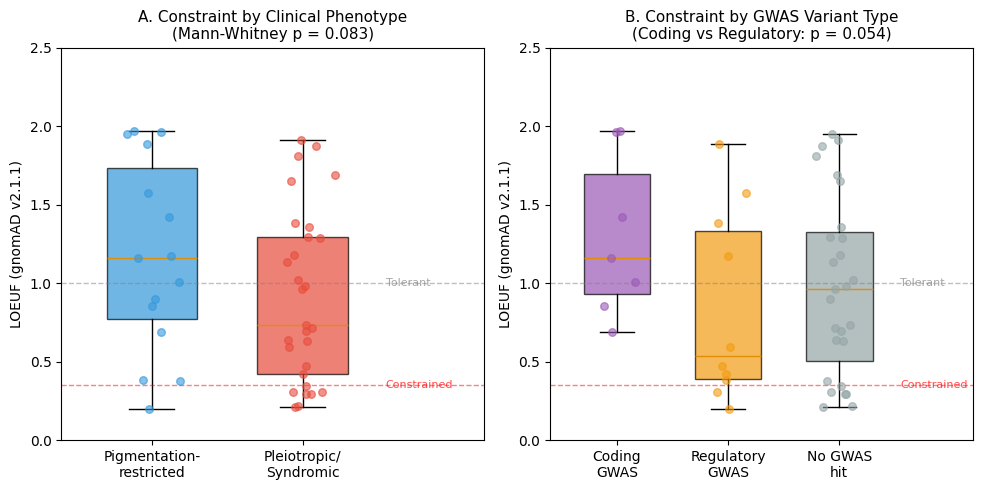


Figure saved to output folder!


In [10]:
# STEP 7: Complete Statistical Analysis and Figure

import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import numpy as np

# Set plot style
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.size'] = 10

# =====================================================================
# ANALYSIS 1: Pigmentation-restricted vs Pleiotropic constraint
# =====================================================================
print("="*70)
print("ANALYSIS 1: CONSTRAINT BY CLINICAL PHENOTYPE")
print("="*70)

restricted = df[df['category'] == 'pigment_restricted']['LOEUF'].dropna().values
pleiotropic = df[df['category'] == 'pleiotropic']['LOEUF'].dropna().values

print(f"Pigmentation-restricted (n={len(restricted)}): median = {np.median(restricted):.2f}")
print(f"Pleiotropic/Syndromic (n={len(pleiotropic)}): median = {np.median(pleiotropic):.2f}")

# Mann-Whitney U test (one-tailed: restricted > pleiotropic)
u_stat_cat, p_category = stats.mannwhitneyu(restricted, pleiotropic, alternative='greater')
print(f"\nMann-Whitney U (restricted > pleiotropic): U = {u_stat_cat}, p = {p_category:.4f}")

# =====================================================================
# ANALYSIS 2: Coding vs Regulatory GWAS
# =====================================================================
print("\n" + "="*70)
print("ANALYSIS 2: CODING vs REGULATORY GWAS")
print("="*70)

coding = df[df['variant_type'] == 'coding']['LOEUF'].dropna().values
regulatory = df[df['variant_type'] == 'regulatory']['LOEUF'].dropna().values
no_gwas = df[df['variant_type'] == 'none']['LOEUF'].dropna().values

print(f"Coding GWAS (n={len(coding)}): median = {np.median(coding):.2f}")
print(f"Regulatory GWAS (n={len(regulatory)}): median = {np.median(regulatory):.2f}")
print(f"No GWAS hit (n={len(no_gwas)}): median = {np.median(no_gwas):.2f}")

u_stat, p_coding_reg = stats.mannwhitneyu(coding, regulatory, alternative='greater')
print(f"\nCoding vs Regulatory (one-tailed): U = {u_stat}, p = {p_coding_reg:.4f}")

# =====================================================================
# ANALYSIS 3: Cross-tabulation - Are coding GWAS hits in restricted genes?
# =====================================================================
print("\n" + "="*70)
print("ANALYSIS 3: CROSS-TABULATION")
print("="*70)

# Create cross-tab
crosstab = pd.crosstab(df['category'], df['variant_type'])
print(crosstab)

# Fisher's exact test for coding variants
contingency = [
    [len(df[(df['category'] == 'pigment_restricted') & (df['variant_type'] == 'coding')]),
     len(df[(df['category'] == 'pigment_restricted') & (df['variant_type'] != 'coding')])],
    [len(df[(df['category'] == 'pleiotropic') & (df['variant_type'] == 'coding')]),
     len(df[(df['category'] == 'pleiotropic') & (df['variant_type'] != 'coding')])]
]
odds_ratio, fisher_p = stats.fisher_exact(contingency)
print(f"\nFisher's exact (coding enriched in restricted?): OR = {odds_ratio:.2f}, p = {fisher_p:.4f}")

# =====================================================================
# FIGURE
# =====================================================================
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Panel A: Pigmentation-restricted vs Pleiotropic
ax1 = axes[0]
category_labels = ['Pigmentation-\nrestricted', 'Pleiotropic/\nSyndromic']
category_data = [restricted, pleiotropic]
colors = ['#3498db', '#e74c3c']

positions = [1, 2]
for i, (data, label, color) in enumerate(zip(category_data, category_labels, colors)):
    bp = ax1.boxplot([data], positions=[positions[i]], widths=0.6, patch_artist=True)
    bp['boxes'][0].set_facecolor(color)
    bp['boxes'][0].set_alpha(0.7)
    jitter = np.random.normal(0, 0.08, len(data))
    ax1.scatter([positions[i]] * len(data) + jitter, data, c=color, alpha=0.6, s=30, zorder=3)

ax1.axhline(y=0.35, color='red', linestyle='--', alpha=0.5, linewidth=1)
ax1.axhline(y=1.0, color='gray', linestyle='--', alpha=0.5, linewidth=1)
ax1.text(2.55, 0.35, 'Constrained', va='center', fontsize=8, color='red', alpha=0.7)
ax1.text(2.55, 1.0, 'Tolerant', va='center', fontsize=8, color='gray', alpha=0.7)

ax1.set_xticks(positions)
ax1.set_xticklabels(category_labels)
ax1.set_ylabel('LOEUF (gnomAD v2.1.1)')
ax1.set_title(f'A. Constraint by Clinical Phenotype\n(Mann-Whitney p = {p_category:.3f})', fontsize=11)
ax1.set_ylim(0, 2.5)
ax1.set_xlim(0.4, 3.2)

# Panel B: GWAS variant type
ax2 = axes[1]
categories = ['Coding\nGWAS', 'Regulatory\nGWAS', 'No GWAS\nhit']
data_lists = [coding, regulatory, no_gwas]
colors2 = ['#9b59b6', '#f39c12', '#95a5a6']

for i, (data, color) in enumerate(zip(data_lists, colors2)):
    bp = ax2.boxplot([data], positions=[i+1], widths=0.6, patch_artist=True)
    bp['boxes'][0].set_facecolor(color)
    bp['boxes'][0].set_alpha(0.7)
    jitter = np.random.normal(0, 0.08, len(data))
    ax2.scatter([i+1] * len(data) + jitter, data, c=color, alpha=0.6, s=30, zorder=3)

ax2.axhline(y=0.35, color='red', linestyle='--', alpha=0.5, linewidth=1)
ax2.axhline(y=1.0, color='gray', linestyle='--', alpha=0.5, linewidth=1)
ax2.text(3.55, 0.35, 'Constrained', va='center', fontsize=8, color='red', alpha=0.7)
ax2.text(3.55, 1.0, 'Tolerant', va='center', fontsize=8, color='gray', alpha=0.7)

ax2.set_xticks([1, 2, 3])
ax2.set_xticklabels(categories)
ax2.set_ylabel('LOEUF (gnomAD v2.1.1)')
ax2.set_title(f'B. Constraint by GWAS Variant Type\n(Coding vs Regulatory: p = {p_coding_reg:.3f})', fontsize=11)
ax2.set_ylim(0, 2.5)
ax2.set_xlim(0.4, 4.2)

plt.tight_layout()
plt.savefig('../output/figure_melanogenesis_constraint.png', dpi=300, bbox_inches='tight')
plt.savefig('../output/figure_melanogenesis_constraint.pdf', bbox_inches='tight')
plt.show()

print("\nFigure saved to output folder!")

## 9. Export Data Tables

In [11]:
# Create supplementary table
df_export = df[['gene_symbol', 'category', 'LOEUF', 'pLI', 'variant_type']].copy()
df_export = df_export.sort_values(['category', 'LOEUF'])
df_export.to_csv('../output/supplementary_table_genes.csv', index=False)
print("Saved: output/supplementary_table_genes.csv")

# Create summary statistics table
summary_stats = []

# Category stats
for cat, data in [('pigment_restricted', restricted), ('pleiotropic', pleiotropic)]:
    summary_stats.append({
        'Category': cat,
        'Type': 'Clinical_phenotype',
        'n': len(data),
        'median_LOEUF': np.median(data),
        'IQR_low': np.percentile(data, 25),
        'IQR_high': np.percentile(data, 75)
    })

# Variant type stats
for vtype, data in [('coding', coding), ('regulatory', regulatory), ('none', no_gwas)]:
    summary_stats.append({
        'Category': vtype,
        'Type': 'GWAS_variant',
        'n': len(data),
        'median_LOEUF': np.median(data),
        'IQR_low': np.percentile(data, 25),
        'IQR_high': np.percentile(data, 75)
    })

df_summary = pd.DataFrame(summary_stats)
df_summary.to_csv('../output/summary_statistics.csv', index=False)
print("Saved: output/summary_statistics.csv")

print("\n" + "="*70)
print("ANALYSIS COMPLETE")
print("="*70)
print(f"""
Key findings:

1. CONSTRAINT BY CLINICAL PHENOTYPE (Mann-Whitney p = {p_category:.4f})
   - Pigmentation-restricted: median LOEUF = {np.median(restricted):.2f} (tolerant)
   - Pleiotropic/Syndromic: median LOEUF = {np.median(pleiotropic):.2f} (constrained)

2. GWAS VARIANT TYPE (Coding vs Regulatory p = {p_coding_reg:.4f})
   - Coding GWAS hits: median LOEUF = {np.median(coding):.2f}
   - Regulatory GWAS hits: median LOEUF = {np.median(regulatory):.2f}

3. CROSS-TABULATION (Fisher's exact p = {fisher_p:.4f}, OR = {odds_ratio:.1f})
   - Coding variants enriched in pigmentation-restricted genes

INTERPRETATION:
Selection constrains pleiotropic genes (low LOEUF), so common pigmentation
variants can only arise as coding changes in pigmentation-restricted genes.
Pleiotropic genes contribute to pigmentation variation via regulatory variants.
""")

Saved: output/supplementary_table_genes.csv
Saved: output/summary_statistics.csv

ANALYSIS COMPLETE

Key findings:

1. CONSTRAINT BY CLINICAL PHENOTYPE (Mann-Whitney p = 0.0828)
   - Pigmentation-restricted: median LOEUF = 1.16 (tolerant)
   - Pleiotropic/Syndromic: median LOEUF = 0.73 (constrained)

2. GWAS VARIANT TYPE (Coding vs Regulatory p = 0.0544)
   - Coding GWAS hits: median LOEUF = 1.16
   - Regulatory GWAS hits: median LOEUF = 0.53

3. CROSS-TABULATION (Fisher's exact p = 0.0002, OR = inf)
   - Coding variants enriched in pigmentation-restricted genes

INTERPRETATION:
Selection constrains pleiotropic genes (low LOEUF), so common pigmentation
variants can only arise as coding changes in pigmentation-restricted genes.
Pleiotropic genes contribute to pigmentation variation via regulatory variants.



## 10. Data Sources and Gene Classification

### Gene Classification Rationale

| Category | Definition | Example Genes | Clinical Phenotype |
|----------|------------|---------------|-------------------|
| **Pigmentation-restricted** | LOF causes isolated pigmentation changes | TYR, OCA2, MC1R, SLC45A2 | OCA1-6, red hair |
| **Pleiotropic** | LOF causes multi-system syndromes | MITF, SOX10, HPS genes, RAB27A | Waardenburg, HPS, Griscelli |

### Data Sources

| Data | Source | Access |
|------|--------|--------|
| Gene classification | OMIM clinical phenotypes | Curated |
| Constraint metrics | gnomAD v2.1.1 | https://gnomad.broadinstitute.org |
| GWAS associations | NHGRI-EBI GWAS Catalog | API query |
| Variant annotations | GWAS Catalog functional class | API query |